# 04 · Modelos B y C: dos codificadores, concatenación y atención cruzada

El modelo A ya está entrenado y me dio el punto de comparación: Dice 0,55 en validación y
los falsos positivos de un litro a 18 mL. Ahora construyo los otros dos, que son la
pregunta del proyecto. Los tres comparten todo (datos, partición, parches, pérdida,
optimizador, presupuesto); lo único que cambia es cómo se juntan el PET y el CT dentro de
la red.

En A, PET y CT entran como dos canales de una misma imagen y se mezclan desde la primera
convolución. En B, cada modalidad baja por su propio codificador y los dos resúmenes se
apilan en el cuello de botella (concatenación) antes de subir por un decodificador común. C
es exactamente B más un bloque de atención cruzada en ese mismo cuello de botella: cada
posición del mapa PET "pregunta" al mapa CT qué hay ahí y suma la respuesta a su propio
mapa antes de apilar. Por eso B contra C aísla el efecto de la atención.

En este cuaderno muestro las tres arquitecturas sobre un parche real, cuento sus
parámetros, verifico que la atención hace lo que dice hacer, mido cuánto tarda cada una en
esta máquina y corro un humo corto de C.

In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

RAIZ = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
from petct.data import split_files, PatchDataset
from petct.models import build_model, count_parameters, describe_models, CrossAttentionFusion, sincos_pos_3d
from petct.train import TrainConfig, train
from petct.device import pick_device, describe_device
from monai.losses import DiceCELoss

device = pick_device()
print("dispositivo:", describe_device())
splits = split_files(RAIZ / "data/manifests/subconjunto.csv", RAIZ / "data/processed")
ds = PatchDataset(splits["train"], patch_size=(96, 96, 96), p_lesion=1.0, cache_size=4, seed=7)
x, y = ds[0]
xb, yb = x[None].to(device), y[None].to(device)
print("parche:", tuple(xb.shape), "vóxeles de lesión:", int(y.sum()))

dispositivo: mps: GPU de Apple (memoria unificada con el sistema)
parche: (1, 2, 96, 96, 96) vóxeles de lesión: 35562


/Users/sebas/Proyectos/proyecto_PETCT_BME423/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1643: FutureWarning: `torch.jit.interface` is deprecated. Please use `torch.compile` instead.
  warnings.warn(


## 1. Los tres modelos, lado a lado

`describe_models` dice qué es cada uno; el conteo de parámetros dice cuánto pesa. B y C
tienen casi el doble de parámetros que A (24 M contra 13 M) porque llevan dos
codificadores, cada uno con el mismo plan de reducción que A (la primera convolución ya
baja a 48³; eso es lo que los hace baratos: 59 gigaflops por parche contra 37 de A).
Preferí mantener ese codificador idéntico al de A, la misma "lupa" por modalidad, antes que
igualar parámetros angostando los canales. La diferencia entre B y C son 0,4 M: el bloque
de atención. Y agrego un control, A+, que es A con canales más anchos hasta llegar a los
parámetros de B: si algún día B gana a A, A+ dice si fue por la fusión o por el tamaño.

Una lección de ingeniería que quedó en la bitácora: mi primera versión de B procesaba la
primera capa a resolución completa y tardaba 4 s por iteración (28 h por corrida, 16 veces
las operaciones de A). Contar gigaflops antes de lanzar 25 000 iteraciones ahorró una
semana.

In [2]:
filas = []
for nombre, desc in describe_models().items():
    m = build_model(nombre)
    with torch.no_grad():
        out = m.to(device)(xb)
    filas.append({"modelo": nombre, "parámetros (M)": round(count_parameters(m) / 1e6, 1),
                  "salida": str(tuple(out.shape)), "qué es": desc})
    del m
tabla = pd.DataFrame(filas)
print(tabla[["modelo", "parámetros (M)", "salida"]].to_string(index=False))
for _, r in tabla.iterrows(): print(f"\n{r['modelo']}: {r['qué es']}")

modelo  parámetros (M)             salida
     A            12.9 (1, 2, 96, 96, 96)
    A+            24.3 (1, 2, 96, 96, 96)
     B            24.0 (1, 2, 96, 96, 96)
     C            24.4 (1, 2, 96, 96, 96)

A: fusión temprana: U-Net 3D con PET y CT como dos canales de entrada

A+: control de capacidad: A con canales ×1,375 (24,3 M, los parámetros de B); separa el efecto de tener más red del de fusionar distinto

B: fusión intermedia: dos codificadores (PET, CT) concatenados en el cuello de botella y en los saltos

C: fusión intermedia: dos codificadores con atención cruzada PET→CT en el cuello de botella (B + atención)


## 2. Qué hace la atención cruzada, en chico

Para verlo sin ruido uso el bloque de atención solo, con mapas pequeños. Tres cosas que
tienen que cumplirse. Primero, para cada posición del PET los pesos sobre las posiciones
del CT suman 1: son una distribución de "a quién le pregunto". Segundo, al inicio la
ganancia `gamma` vale 0, así que la salida es idéntica al mapa PET: C arranca siendo B, y
solo durante el entrenamiento la red decide cuánto usar la atención. Tercero, la
codificación de posición da a cada posición un código distinto; sin ella la atención no
sabría que una región está arriba y otra abajo.

pesos de atención: (1, 60, 60) (consultas del PET × posiciones del CT); suma por consulta: 1.0
gamma inicial: 0.0 → ¿salida idéntica al PET? True


/var/folders/3r/zv202tcx70l9blnhmnpbw1kc0000gn/T/ipykernel_10355/1304559784.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  print("gamma inicial:", float(blk.gamma), "→ ¿salida idéntica al PET?", bool(torch.allclose(fused, pet)))


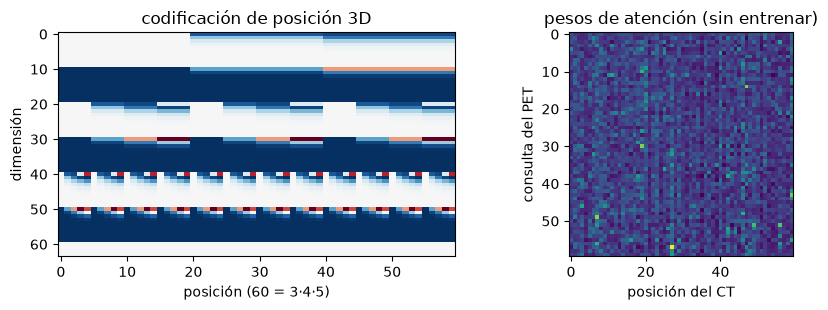

In [3]:
torch.manual_seed(0)
blk = CrossAttentionFusion(64, heads=4)
pet = torch.randn(1, 64, 3, 4, 5); ct = torch.randn(1, 64, 3, 4, 5)
fused = blk(pet, ct)
w = blk.attention_maps(pet, ct)
print("pesos de atención:", tuple(w.shape), "(consultas del PET × posiciones del CT); suma por consulta:", float(w.sum(-1).mean()))
print("gamma inicial:", float(blk.gamma), "→ ¿salida idéntica al PET?", bool(torch.allclose(fused, pet)))
pe = sincos_pos_3d((3, 4, 5), 64, "cpu", torch.float32)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].imshow(pe.numpy().T, aspect="auto", cmap="RdBu"); ax[0].set_xlabel("posición (60 = 3·4·5)"); ax[0].set_ylabel("dimensión"); ax[0].set_title("codificación de posición 3D")
ax[1].imshow(w[0].numpy(), cmap="viridis"); ax[1].set_xlabel("posición del CT"); ax[1].set_ylabel("consulta del PET"); ax[1].set_title("pesos de atención (sin entrenar)")
plt.tight_layout(); plt.show()

## 3. Cuánto tarda cada uno aquí

La misma medición del cuaderno 03, ahora para los cuatro modelos: segundos por iteración
de ida y vuelta con lote 2 y parches de 96³. Por operaciones, B y C deberían tardar entre
1,5 y 2 veces lo que A. Con eso sé cuántas horas son las 25 000 iteraciones de cada uno.

In [4]:
loss_fn = DiceCELoss(softmax=True, to_onehot_y=True, include_background=False)
xb2 = torch.stack([ds[i][0] for i in range(2)]).to(device); yb2 = torch.stack([ds[i][1] for i in range(2)]).to(device)
def sync():
    if device.type == "cuda": torch.cuda.synchronize()
    elif device.type == "mps": torch.mps.synchronize()
res = []
for nombre in ("A", "A+", "B", "C"):
    m = build_model(nombre).to(device); opt = torch.optim.AdamW(m.parameters(), lr=3e-4)
    def paso():
        opt.zero_grad(set_to_none=True); loss = loss_fn(m(xb2), yb2); loss.backward(); opt.step()
    for _ in range(2): paso()
    sync(); t = time.time()
    for _ in range(4): paso()
    sync(); s_it = (time.time() - t) / 4
    res.append({"modelo": nombre, "s/it": round(s_it, 2), "horas 25 000 it": round(25000 * s_it / 3600, 1)})
    del m, opt
print(pd.DataFrame(res).to_string(index=False))

modelo  s/it  horas 25 000 it
     A  0.59              4.1
    A+  0.94              6.5
     B  0.71              4.9
     C  0.71              4.9


## 4. Humo de C con datos reales

Como con A: 100 iteraciones de la red chica con parches de 64³, solo para comprobar que el
bucle completo funciona con dos codificadores y atención, que la pérdida baja y que el
checkpoint se guarda. No es un resultado.

modelo C (chico): 2.3 M parámetros | 176 estudios de entrenamiento, 1 de validación rápida | dispositivo mps | AMP no | lote 2 | parche (64, 64, 64)


it     10  loss 1.4431  lr 9.19e-04  0.23 s/it


it     20  loss 1.1830  lr 8.27e-04  0.22 s/it


it     30  loss 1.0536  lr 7.35e-04  0.22 s/it


it     40  loss 1.0280  lr 6.41e-04  0.22 s/it


...

it     80  loss 0.8564  lr 2.45e-04  0.22 s/it


it     90  loss 0.9626  lr 1.37e-04  0.23 s/it


it    100  loss 0.9011  lr 1.58e-05  0.22 s/it


  [val it 100] Dice(pos) 0.000  FPV 1011 mL  FNV 1.6 mL  ← mejor


{'modelo': 'C', 'parametros': 2312824, 'iteraciones_hechas': 100, 'loss_final': 0.913968162536621, 'minutos': 0.41824891567230227}
gamma tras el humo: 0.012072237208485603 (partió en 0; si se mueve, la red está usando la atención)


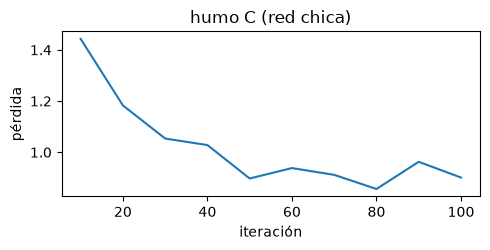

In [5]:
cfg = TrainConfig(modelo="C", iteraciones=100, lote=2, lr=1e-3, checkpoint_cada=50, validar_cada=100,
                  max_estudios_val=1, parche=(64, 64, 64), prob_parche_con_lesion=0.8, semilla=423,
                  workers=0, cache_estudios=16, small=True, log_cada=10)
salida = RAIZ / "runs" / "humo_C_cuaderno"
res = train(cfg, splits["train"], splits["val"], salida, device, resume=True)
print({k: v for k, v in res.items() if k in ("modelo", "parametros", "iteraciones_hechas", "loss_final", "minutos")})
log = pd.read_csv(salida / "log_entrenamiento.csv")
ck = torch.load(salida / "ultimo.pt", map_location="cpu", weights_only=False)
print("gamma tras el humo:", float(ck["model"]["cross.gamma"]), "(partió en 0; si se mueve, la red está usando la atención)")
plt.figure(figsize=(5, 2.6)); plt.plot(log["iter"], log["loss"]); plt.xlabel("iteración"); plt.ylabel("pérdida"); plt.title("humo C (red chica)"); plt.tight_layout(); plt.show()

## 5. Qué sigue

Las nueve corridas: A, B y C con semillas 423, 2 y 3, con `scripts/07_entrenar.py --modelo
B --semilla 2 --salida runs/B_s2` y equivalentes. Cada una se evalúa en validación con
`scripts/09` y `scripts/10` arma la tabla con media y desviación por modelo. La prueba se
abre una sola vez al final. Después, con las máscaras guardadas y las máscaras de órganos
del CT, el análisis por órgano del Paso 5, que es donde la pregunta del proyecto se
responde de verdad: no solo cuánto se equivoca cada fusión, sino dónde.